# Module 1 — The Business Impact Engine, step by step

**What this notebook does, in one sentence:** it takes the model's risk scores
(a number between 0 and 1 for every machine, every week) and turns them into
**money** — so a service manager can justify the weekly inspection round to their boss.

**The three "magic numbers" everything is built on (our disclosed assumptions):**

| Assumption | Value | Where it comes from |
|---|---|---|
| One day of unplanned downtime costs | **$27,000** | lost scan revenue, order-of-magnitude |
| One proactive inspection visit costs | **$800** | engineer day + travel |
| Weekly inspection budget | **20 machines** | a realistic team capacity |

So: missing a failure is ~100× more expensive than a wasted visit. That asymmetry
is the reason this whole product exists.

Run each cell with **Shift+Enter** and read the output before moving on.

## Step 0 — Setup: load the model's scores

The model already ran (that's `train_xgb.py`). It left behind `scores.parquet`:
**one row per machine per week**, with `risk_calibrated` — the model's honest
estimate of "probability this machine fails in the next 7 days".
"Calibrated" means a 0.40 really behaves like a 40% chance — we can multiply money by it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)

# find the repo root by walking up until we see the data folder
_start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
for _dir in [_start, *_start.parents]:
    if (_dir / "data" / "raw").exists():
        ML = _dir
        break
plt.style.use(ML.parent / "design" / "fleetpulse.mplstyle")

DAY_COST = 27_000   # $ per day of unplanned downtime
VISIT = 800         # $ per proactive inspection
K = 20              # weekly worklist size

scores = pd.read_parquet(ML / "data" / "app" / "scores.parquet")
failures = pd.read_parquet(ML / "data" / "raw" / "failures.parquet")
fleet = pd.read_parquet(ML / "data" / "raw" / "fleet_master.parquet")

print(f"scores: {scores.shape[0]:,} rows — one per machine per week")
scores.head()

Duplicate key in file PosixPath('/Users/shamanth/Desktop/Cursor/Deeksh Personal/fleet-pulse/design/fleetpulse.mplstyle'), line 30 ("axes.prop_cycle: cycler('color', ['0E8A92', '17B9C0', 'C67F14', '5F8B92', '0A4B52', '1F9E78', 'D64545'])")


scores: 24,867 rows — one per machine per week


,machine_id,date,split,label,days_to_failure,risk_raw,risk_calibrated
0,FP-CT-0001,2025-02-24,train,0,9.0,0.847044,0.236084
1,FP-CT-0001,2025-05-12,train,0,NaN,0.049002,0.001824
2,FP-CT-0002,2025-03-17,train,0,26.0,0.313706,0.009922
3,FP-CT-0002,2025-05-19,train,0,64.0,0.166574,0.003877
4,FP-CT-0003,2025-03-03,train,0,NaN,0.027584,0.001590


**What you're looking at:** each row says *"machine X, on week-ending date D,
had risk_calibrated probability of failing in the following 7 days"*.
`label` is the answer key (1 = it really did fail within 7 days) — we only know
it because this is historical data. `split` tells us which rows the model was
trained on (`train`) vs which were kept hidden for honest testing (`test`).

## Step 1 — Take the latest week: what does the fleet look like *right now*?

The impact engine's first job is the **decision view**: it's Monday morning,
we have 500 machines and 500 risk numbers. How is risk spread out?

As-of week: 2025-12-29 — 476 machines


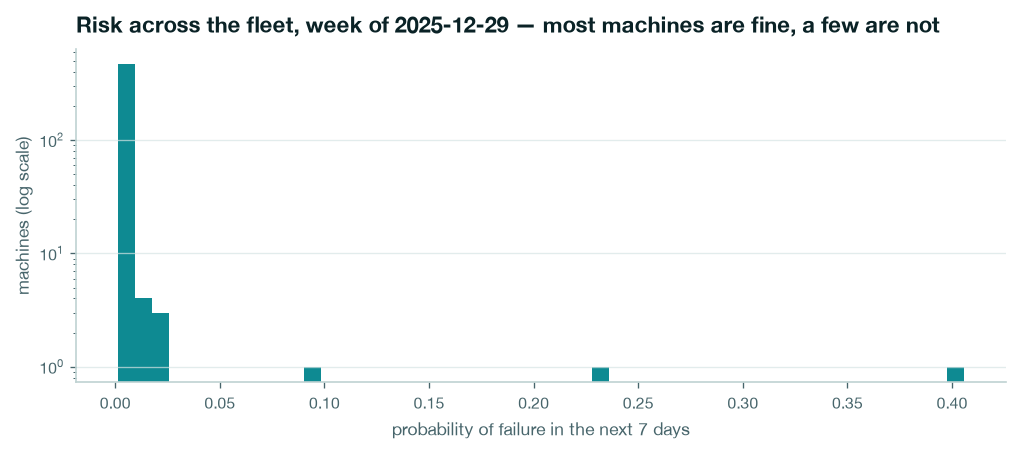

In [2]:
as_of = scores["date"].max()
week = scores[scores["date"] == as_of].copy()
print(f"As-of week: {as_of.date()} — {len(week)} machines")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(week["risk_calibrated"], bins=50, color="#0E8A92")
ax.set_yscale("log")  # log scale: otherwise the healthy machines flatten everything
ax.set_xlabel("probability of failure in the next 7 days")
ax.set_ylabel("machines (log scale)")
ax.set_title(f"Risk across the fleet, week of {as_of.date()} — most machines are fine, a few are not", loc="left")
plt.show()

**Read the chart like this:** almost everyone is piled up near zero (healthy),
and a small tail stretches right — those are the machines the model is worried
about. The whole business case lives in that tail.

## Step 2 — Turn each probability into dollars: "expected loss"

Explain-like-I'm-5: if there's a 30% chance you lose \$100, your *expected loss*
is \$30. It's what that risk costs you **on average** if you do nothing.

For a machine:

```
expected_loss = P(fails this week) × (typical downtime days) × ($ per down day)
```

Typical downtime = the **median** from the failures table (median, not mean,
so one freak 10-day outage doesn't distort every estimate).

In [3]:
med_downtime = failures["downtime_days"].median()
print(f"typical (median) downtime per failure: {med_downtime} days")

week["expected_loss_usd"] = week["risk_calibrated"] * med_downtime * DAY_COST
week = week.sort_values("risk_calibrated", ascending=False)

top10 = week.head(10).merge(fleet[["machine_id", "modality", "country"]], on="machine_id")
top10[["machine_id", "modality", "country", "risk_calibrated", "expected_loss_usd"]].round(3)

typical (median) downtime per failure: 2.0 days


,machine_id,modality,country,risk_calibrated,expected_loss_usd
0,FP-CT-0124,CT,DE,0.406,21900.308594
1,FP-MRI-0066,MRI,DE,0.230,12412.948242
2,FP-CT-0040,CT,AU,0.097,5238.763184
3,FP-CT-0202,CT,GB,0.025,1350.479004
4,FP-CT-0189,CT,GB,0.023,1217.386963
5,FP-MRI-0104,MRI,US,0.022,1208.597046
6,FP-MRI-0065,MRI,US,0.012,660.153992
7,FP-MRI-0095,MRI,GB,0.012,629.919006
8,FP-MRI-0011,MRI,GB,0.011,604.388000
9,FP-CT-0125,CT,ES,0.011,599.291992


**Read the table like this:** the riskiest machine has a real, calibrated
probability of failing this week — multiplied out, leaving it alone "costs"
thousands of expected dollars. A healthy machine's expected loss is near zero.

## Step 3 — The Monday decision: is the top-20 worklist worth it?

We can afford 20 inspections a week (20 × \$800 = \$16,000).
The bet: **an inspection converts a would-be breakdown into a planned visit** —
the downtime cost is avoided (the repair itself happens either way, so we
leave repair cost out of both sides of the equation — that's fair accounting).

expected downtime loss across the whole fleet this week : $   106,796
expected loss sitting in just the top-20 machines        : $    49,505
cost of inspecting those 20 machines                     : $    16,000
expected net savings from this week's worklist           : $    33,505


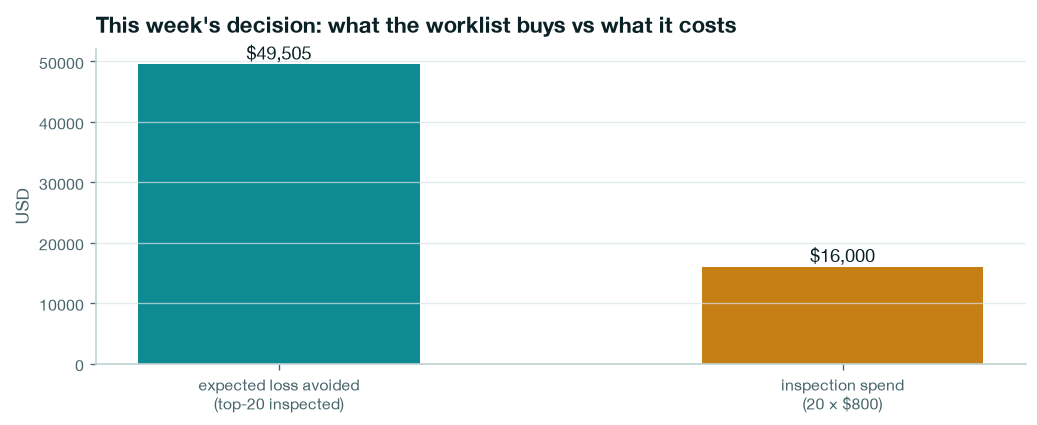

In [4]:
top20 = week.head(K)
expected_avoided = top20["expected_loss_usd"].sum()
spend = K * VISIT
fleet_at_risk = week["expected_loss_usd"].sum()

print(f"expected downtime loss across the whole fleet this week : ${fleet_at_risk:>10,.0f}")
print(f"expected loss sitting in just the top-{K} machines        : ${expected_avoided:>10,.0f}")
print(f"cost of inspecting those {K} machines                     : ${spend:>10,.0f}")
print(f"expected net savings from this week's worklist           : ${expected_avoided - spend:>10,.0f}")

fig, ax = plt.subplots(figsize=(10, 3.4))
bars = ax.bar(["expected loss avoided\n(top-20 inspected)", "inspection spend\n(20 × $800)"],
              [expected_avoided, spend], color=["#0E8A92", "#C67F14"], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 800, f"${b.get_height():,.0f}",
            ha="center", fontsize=11)
ax.set_title("This week's decision: what the worklist buys vs what it costs", loc="left")
ax.set_ylabel("USD")
plt.show()

**This is the chart P1 (the operations manager) uses to defend her dispatch
decisions.** Note it's an *expected value* — some inspected machines were false
alarms, some real failures aren't in the top 20. Which is why we don't stop here…

## Step 4 — The proof: replay history and count the actual money

Expected values are promises. The **backtest** is receipts.

The model never saw Nov–Dec 2025 during training (the held-out `test` split).
So we can play time machine: go back to each of those 9 Mondays, pretend we
ran the top-20 worklist, and check against reality:
- failure was in our top-20 → **caught** (downtime avoided)
- failure was NOT in our top-20 → **missed** (downtime cost hits us in full)

In [5]:
test = scores[scores["split"] == "test"]
weeks = sorted(test["date"].unique())

rows = []
for wk in weeks:
    snap = test[test["date"] == wk].sort_values("risk_calibrated", ascending=False)
    flagged = set(snap.head(K)["machine_id"])
    for _, r in snap[snap["label"] == 1].iterrows():
        f = failures[(failures["machine_id"] == r["machine_id"])
                     & (failures["failure_date"] > wk)
                     & (failures["failure_date"] <= wk + pd.Timedelta(days=7))]
        days = f["downtime_days"].sum() if len(f) else med_downtime
        rows.append({"week": pd.Timestamp(wk).date(), "machine_id": r["machine_id"],
                     "caught": r["machine_id"] in flagged, "downtime_days": days})

bt = pd.DataFrame(rows)
weekly = bt.groupby("week")["caught"].agg(caught="sum", total="count")
weekly["missed"] = weekly["total"] - weekly["caught"]
print(f"{bt['caught'].sum()} caught / {len(bt)} failures across {len(weeks)} weeks")
weekly

41 caught / 54 failures across 9 weeks


,caught,total,missed
week,,,
2025-11-03,7,7,0
2025-11-10,7,9,2
2025-11-17,8,12,4
2025-11-24,1,3,2
2025-12-01,4,5,1
2025-12-08,5,5,0
2025-12-15,3,7,4
2025-12-22,5,5,0
2025-12-29,1,1,0


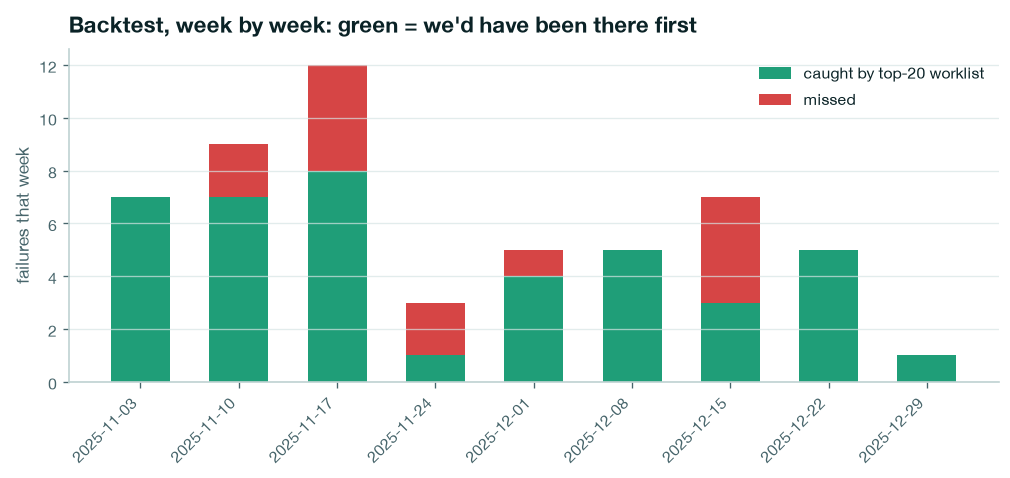

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6))
x = range(len(weekly))
ax.bar(x, weekly["caught"], label="caught by top-20 worklist", color="#1F9E78", width=0.6)
ax.bar(x, weekly["missed"], bottom=weekly["caught"], label="missed", color="#D64545", width=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels([str(w) for w in weekly.index], rotation=45, ha="right")
ax.set_ylabel("failures that week")
ax.set_title("Backtest, week by week: green = we'd have been there first", loc="left")
ax.legend()
plt.show()

## Step 5 — Put dollars on the backtest

Three numbers, one comparison:
- **do nothing**: every failure's downtime hits us → total downtime × \$27k
- **with the worklist**: caught failures' downtime avoided; we pay for
  9 weeks × 20 visits; missed failures still hurt us

downtime days avoided (caught failures)  : 104 days
downtime cost avoided                    : $2,808,000
inspection spend (9 wks × 20 × $800)     : $144,000
NET SAVINGS over the 2-month test window : $2,664,000
vs doing nothing ($3,618,000 downtime cost): we cut it by 77.6%


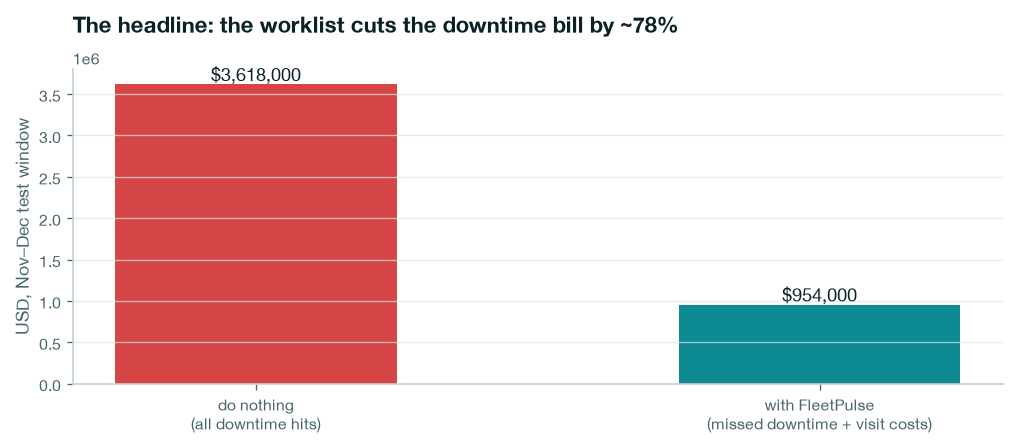

In [7]:
caught_days = bt.loc[bt["caught"], "downtime_days"].sum()
missed_days = bt.loc[~bt["caught"], "downtime_days"].sum()

avoided = caught_days * DAY_COST
spend_bt = len(weeks) * K * VISIT
do_nothing = (caught_days + missed_days) * DAY_COST
net = avoided - spend_bt

print(f"downtime days avoided (caught failures)  : {caught_days:.0f} days")
print(f"downtime cost avoided                    : ${avoided:,.0f}")
print(f"inspection spend ({len(weeks)} wks × {K} × ${VISIT})     : ${spend_bt:,.0f}")
print(f"NET SAVINGS over the 2-month test window : ${net:,.0f}")
print(f"vs doing nothing (${do_nothing:,.0f} downtime cost): we cut it by {100*avoided/do_nothing:.1f}%")

fig, ax = plt.subplots(figsize=(10, 3.4))
bars = ax.bar(["do nothing\n(all downtime hits)", "with FleetPulse\n(missed downtime + visit costs)"],
              [do_nothing, missed_days * DAY_COST + spend_bt], color=["#D64545", "#0E8A92"], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 40_000, f"${b.get_height():,.0f}",
            ha="center", fontsize=11)
ax.set_ylabel("USD, Nov–Dec test window")
ax.set_title("The headline: the worklist cuts the downtime bill by ~78%", loc="left")
plt.show()

## Step 6 — The sanity check (never skip this)

The money numbers must agree with the model metrics — if they don't,
something is broken. Recall@20 said the top-20 list captures ~78% of failures.
Our backtest just counted the catches by hand. Do they match?

In [8]:
import json
metrics = json.load(open(ML / "data" / "app" / "metrics.json"))
print(f"recall@20 from model evaluation : {metrics['recall_at_20']:.3f}")
print(f"caught/total from our backtest  : {bt['caught'].sum()}/{len(bt)} = {bt['caught'].mean():.3f}")
print("→ same story, told twice — metrics for the data scientist, dollars for the director.")

recall@20 from model evaluation : 0.778
caught/total from our backtest  : 41/54 = 0.759
→ same story, told twice — metrics for the data scientist, dollars for the director.


## What to say in the interview (the 30-second version)

> "My model's recall@20 is 0.78 — but what I'd tell your service director is:
> in the two-month test window the weekly top-20 worklist would have caught
> 41 of 54 failures, avoided 104 days of unplanned downtime, and saved about
> **\$2.7M net** after paying for every inspection — a ~78% cut in the downtime
> bill. All on disclosed assumptions: \$27k per down-day, \$800 per visit."

**The production version of this notebook** is `ml/src/models/impact.py` — the
same logic as a script, which writes `impact.json` for the dashboard to read.

### Honest limits (know these cold)
- "Inspection prevents the downtime" is an **assumption** — in reality prevention
  isn't 100%; a sensitivity check (50% / 75% effectiveness) still nets positive.
- The \$27k/day is an order-of-magnitude industry figure, not a measured one.
- Synthetic data: failure rates are upsampled so one year is trainable — the
  *percentages* are meaningful, absolute dollars scale with the assumptions.